In [1]:
from skimage import io

from MEDUSSA.measure import SizeDataFrame
from MEDUSSA.transform import ParamSampler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

import time
from glob import glob

In [2]:
df_posteriors = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/FigS8_posterior_segmentation_measurements.csv')

ponA_cryo = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/Fig4_ponA_cryo.csv')
ponA_cryo['Size (nm)'] = ponA_cryo['Scale (px to nm)']*ponA_cryo['Size (px)']
ponA_widths = np.array(ponA_cryo['Size (nm)']/1000)

ponA_cryo = pd.DataFrame()
ponA_cryo.insert(0,'Width_mu',ponA_widths)
ponA_cryo.insert(0,'Strain','∆ponA')
ponA_cryo.insert(1,'Method','Cryo-EM')


PY79_cryo3 = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/Fig4_WT_cryo.csv')
PY79_widths = np.array(PY79_cryo3['Size (nm)']/1000)

PY79_cryo = pd.DataFrame()
PY79_cryo.insert(0,'Width_mu',PY79_widths)
PY79_cryo.insert(0,'Strain','PY79')
PY79_cryo.insert(1,'Method','Cryo-EM')


ponA_fm = sorted(glob('/Users/reyesmatte/Desktop/SingleCells/PY79vsPonA/FM4/*JLG251*curated_masks.tif'))
ponA_fm = SizeDataFrame(ponA_fm)
ponA_fm.insert(0,'Strain','∆ponA')
ponA_fm.insert(1,'Method','FM')
ponA_fm = ponA_fm[['Strain','Method','Width']]
ponA_fm = ParamSampler(data_df=ponA_fm,posterior_df=df_posteriors,columns=['Strain','Method'],metrics=['Width'])
ponA_fm = ponA_fm[ponA_fm['Width_mu'] > 0]

py79_fm = sorted(glob('/Users/reyesmatte/Desktop/SingleCells/PY79vsPonA/FM4/*PY79*curated_masks.tif'))
py79_fm = SizeDataFrame(py79_fm)
py79_fm.insert(0,'Strain','PY79')
py79_fm.insert(1,'Method','FM')
py79_fm = py79_fm[['Strain','Method','Width']]
py79_fm = ParamSampler(data_df=py79_fm,posterior_df=df_posteriors,columns=['Strain','Method'],metrics=['Width'])
py79_fm = py79_fm[py79_fm['Width_mu'] > 0]

full_df = pd.concat([ponA_cryo,PY79_cryo,ponA_fm,py79_fm],ignore_index=True)
full_df.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/Fig4_violins.csv')

/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/var/folders/q6/szs86xgn755_g81_n0cyblxc0000gp/T/ipykernel_26603/4063807745.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['FM4-64\ndeconvolved','CryoEM'],fontsize=12)
/var/folders/q6/szs86xgn755_g81_n0cyblxc0000gp/T/ipykernel_26603/4063807745.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['FM4-64\ndeconvolved','Cryo EM'],fontsize=12)


FM, difference = 0.34%


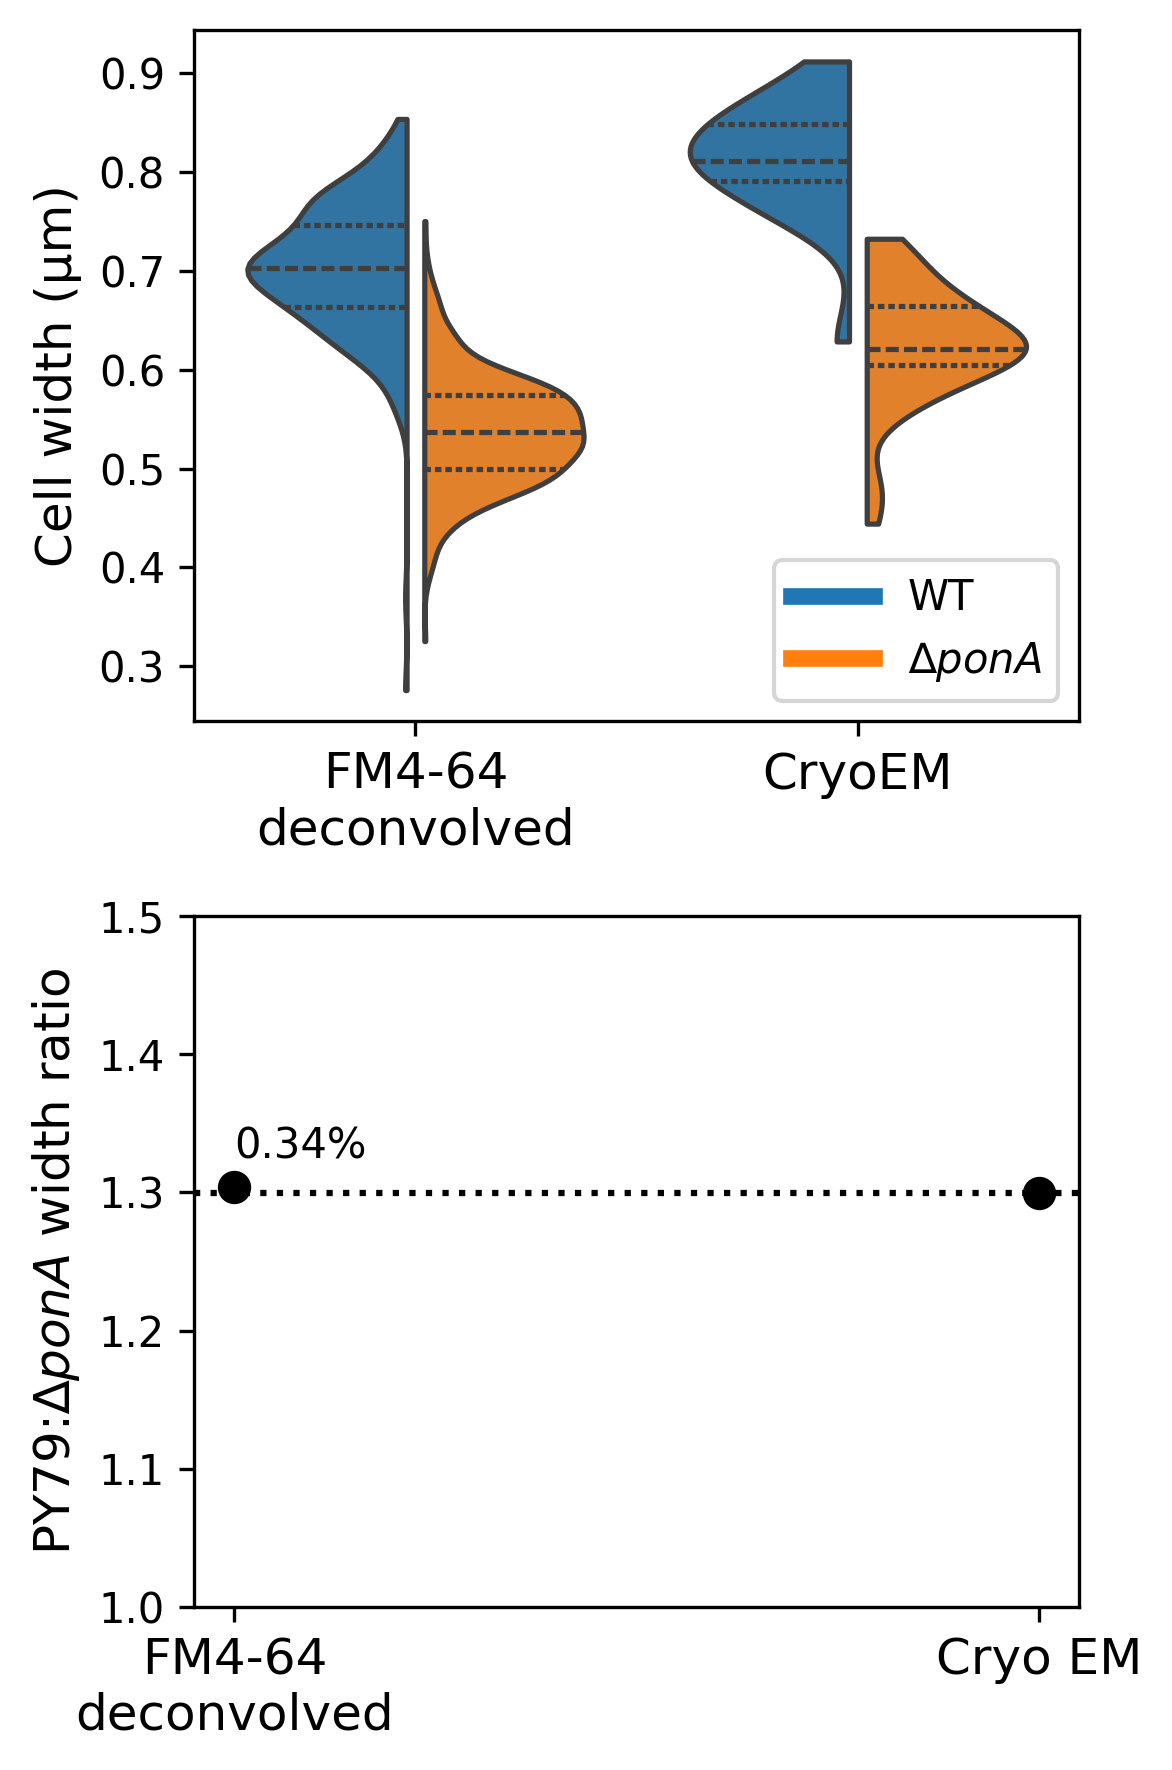

In [3]:
full_df = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/Fig4_violins.csv')

fig,ax = plt.subplots(dpi=300,figsize=(4,6),ncols=1,nrows=2)

palette = sns.color_palette("tab10")[:2]

methods = ['FM','Cryo-EM']

sns.violinplot(x=full_df['Method'],y=full_df['Width_mu'],hue=full_df['Strain'],density_norm='width',cut=0,split=True,
               inner='quartile',gap=0.1,palette=palette,ax=ax[0],order=methods,hue_order=['PY79','∆ponA'])
ax[0].set_xticklabels(['FM4-64\ndeconvolved','CryoEM'],fontsize=12)
ax[0].set_ylabel('Cell width (µm)',fontsize=12)
ax[0].set_xlabel('')

handles = [Line2D([0], [0], color=c, lw=4) for c in palette]

ax[0].legend(handles=handles,labels=["WT","∆$ponA$"])


ys = []

for i,method in enumerate(methods):

    subdf = full_df[full_df['Method'] == method]

    wt = subdf[subdf['Strain'] == 'PY79']
    pbp = subdf[subdf['Strain'] != 'PY79']

    ys.append(wt['Width_mu'].mean()/pbp['Width_mu'].mean())


ax[1].plot(methods,ys,'o',c='k',markersize=7)

for y,method in zip(ys,methods):

    diffperc = abs(1-(y/ys[-1]))*100

    if method != methods[-1]: 
        print(f"{method}, difference = {diffperc:.2f}%")
        ax[1].text(x=method,y=y+0.02,s=f'{diffperc:.2f}%')

ax[1].set_xticklabels(['FM4-64\ndeconvolved','Cryo EM'],fontsize=12)
ax[1].set_ylabel('PY79:∆$ponA$ width ratio',fontsize=12)
ax[1].set_xlabel('')
ax[1].axhline(y=ys[-1],c='k',linestyle=':')
ax[1].set_ylim(1,1.5)

fig.tight_layout()
#fig.savefig('/Users/reyesmatte/Desktop/Imaging_paper/Fig4/CryoEM_vs_Fluo_vertical.png')

In [5]:
full_df.groupby(['Strain','Method']).mean()

Width_mu  Width_sigma
Strain Method                        
PY79   Cryo-EM  0.814630          NaN
       FM       0.702207     0.000852
∆ponA  Cryo-EM  0.626756          NaN
       FM       0.538416     0.001506